In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
from tqdm import tqdm
import pandas as pd

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='white', context='notebook', rc={'figure.figsize':(6,6)}, font_scale=1.5)

2.3.0+cu121
12.1
2.3.0+cu121
12.1


In [37]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import load_cluster_data as llc 

# Append also simulation directory
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import simulate_counts as sim 
reload (sim)

sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/")
import vis as vis

### Settings

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cpu


### Load junction and intron cluster counts

In [4]:
# let's simulate using the mammary gland data
input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/"

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, remove_singletons=True, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  157665
Number of junctions after removing singletons:  47015
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  2405
The number of unique junctions in the data is:  47016
The maximum junction count was initially:  251545
375
The maximum junction count is now:  4999
The number of junctions in the data is:  44087
The number of cells in the data is:  2405
The number of cell types in the data is:  4


In [5]:
# double check which cell types are present
cell_ids_conversion.cell_type.value_counts()

cell_type
Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: count, dtype: int64

In [6]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

cell_id_index                                                     1202
junction_id_index                                                41341
junc_count                                                         0.0
cluster_count                                                        4
clustminjunc                                                       4.0
juncratio                                                          0.0
cell_id              I17-B002433-3_38_F-1-1_Mammary_Gland_stromal_cell
cell_type                                   Mammary_Gland_stromal_cell
junction_id                                      2_110022014_110040573
Cluster                                                           8368
gene_id                                                         Ccdc34
Name: 12426125, dtype: object
0.0
4


### For simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions 

In [7]:
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = junction_ids_conversion[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]

# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

6594


In [8]:
# run function on all clusters to find simple exon skipping events 
clusters_SS = []

for cluster in tqdm(junc_info["Cluster"].unique()): # this is very slow
    clusters_SS.append(sim.check_SS_cluster(final_data, junc_info, cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

# get indices of junctions in clusters_SS (original indices before filtering)
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
print(len(junc_ind_keep))
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)] #using original junction id index

# filter junction_ids file to only include junctions in clusters_SS
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["junction_id_index"].isin(junc_ind_keep)]
# reset index of junction_ids_conversion and make a new column new_junction_id_index
junction_ids_conversion = junction_ids_conversion.reset_index(drop=True)
# re-order junction_ids_conversion junction_id_index
junction_ids_conversion = junction_ids_conversion.sort_values(by=['junction_id_index'])
junction_ids_conversion["new_junction_id_index"] = junction_ids_conversion.index
print(junction_ids_conversion.head())

# re-order the remaining junctions and subset the counts matrices
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index", "Cluster", "junction_id"])

# where is new_junction_id_index coming from here? 
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)
final_data.head()

to_keep = final_data["junction_id_index"].unique()   # use original junction indices to filter out the count matrices 
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

100%|██████████| 6594/6594 [03:11<00:00, 34.48it/s]


6388
19164
   junction_id_index          junction_id  Cluster gene_id  \
0                 12  1_78692220_78694195      114   Acsl3   
1                 13  1_78694346_78696080      114   Acsl3   
2                 20  1_74236899_74246079      344   Arpc2   
3                 21  1_74246114_74248131      344   Arpc2   
4                 22  1_74255014_74255957      347   Arpc2   

   new_junction_id_index  
0                      0  
1                      1  
2                      2  
3                      3  
4                      4  


In [9]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])
print(cluster_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])

cell_id_index                                                       805
junction_id_index                                                 22429
junc_count                                                          0.0
cluster_count                                                        10
clustminjunc                                                       10.0
juncratio                                                           0.0
cell_id                  F5-B002433-3_38_F-1-1_Mammary_Gland_basal_cell
cell_type                                      Mammary_Gland_basal_cell
junction_id                                          10_4439736_4450646
Cluster                                                           66657
gene_id_x                                                 1700052N19Rik
gene_id_y                                                 1700052N19Rik
new_junction_id_index                                             10065
Name: 3230617, dtype: object
0.0
10


<Axes: xlabel='juncratio', ylabel='Count'>

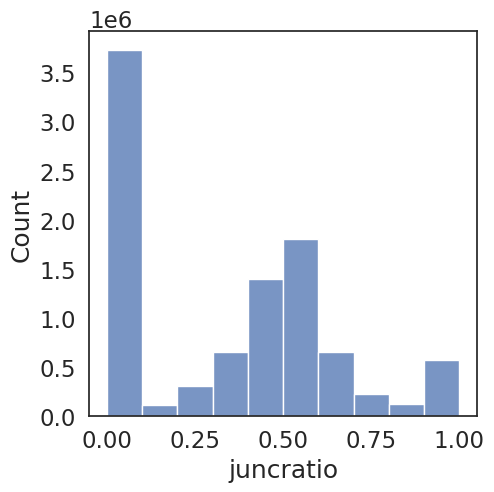

In [10]:
# set figure size to be small
plt.figure(figsize=(5,5))
sns.histplot(final_data.juncratio, bins=10)

### Let's simulate some data!

In [11]:
# update junc_info to only include junctions in clusters_SS
junc_info = junc_info[junc_info["Cluster"].isin(clusters_SS)]
junc_info = junc_info.reset_index(drop=True)
junc_info["new_junction_id_index"] = junc_info.index
junc_info.head()

,junction_id,Cluster,junction_id_index,chr,start,end,new_junction_id_index
0,1_78692220_78694195,114,12,1,78692220,78694195,0
1,1_78694346_78696080,114,13,1,78694346,78696080,1
2,1_74236899_74246079,344,20,1,74236899,74246079,2
3,1_74246114_74248131,344,21,1,74246114,74248131,3
4,1_74255014_74255957,347,22,1,74255014,74255957,4


In [12]:
cell_ids_conversion.cell_type.value_counts()

cell_type
Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: count, dtype: int64

In [13]:
print(len(junc_info.junction_id.unique()))
print(len(junc_info.Cluster.unique()))

19164
6388


In [14]:
cell_ids_conversion["cell_type"] = np.random.choice([1,2], size=len(cell_ids_conversion))
cell_ids_conversion

,cell_id_index,cell_id,cell_type
6,0,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,2
17029,1,A10-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,1
39773,2,A10-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,1
58704,3,A10-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,2
93362,4,A10-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,1
...,...,...,...
38830678,2400,P9-B002432-3_38_F-1-1_Mammary_Gland_basal_cell,1
38842981,2401,P9-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,1
38856962,2402,P9-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,1
38880113,2403,P9-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,1


In [15]:
simulated_counts, cell_types, cell_type_psi, cluster_labels = sim.simulate_junc_counts(cluster_counts_sub, junc_info, cell_types=cell_ids_conversion.cell_type.astype('category'))

Using pre-defined cell types!
The number of cell types is: 2
The number of cells is: 2405
The number of junctions is: 19164


100%|██████████| 6388/6388 [00:19<00:00, 333.62it/s]


The columns to keep are: Index([0, 1], dtype='object')
Done simulating PSI!
Done simulating junc counts!


In [16]:
# Check outcome of cluster_labels
print(cluster_labels)

           0         1  new_junction_id_index sample_label  Cluster
0   0.422694  0.422694                      0     negative      114
2   0.422694  0.422694                      1     negative      114
0   0.335422  0.081455                      2     positive      344
2   0.335422  0.081455                      3     positive      344
0   0.253225  0.253225                      4     negative      347
..       ...       ...                    ...          ...      ...
1   0.102305  0.102305                  19159     negative      219
1   0.634932  0.634932                  19160     negative   116052
1   0.416542  0.000150                  19161     positive    23116
1   0.920100  0.920100                  19162     negative   118988
1   0.543716  0.679523                  19163     positive    75653

[19164 rows x 5 columns]


In [17]:
# save simulated counts, cell types and psi values
sim_juncs_counts = simulated_counts
cell_type_psi_df = cluster_labels

In [18]:
# get variance in simulated psi values across all simulated cell types 
K = len(np.unique(cell_types))
print(K)

2


In [19]:
cell_type_psi_df

,0,1,new_junction_id_index,sample_label,Cluster
0,0.422694,0.422694,0,negative,114
2,0.422694,0.422694,1,negative,114
0,0.335422,0.081455,2,positive,344
2,0.335422,0.081455,3,positive,344
0,0.253225,0.253225,4,negative,347
...,...,...,...,...,...
1,0.102305,0.102305,19159,negative,219
1,0.634932,0.634932,19160,negative,116052
1,0.416542,0.000150,19161,positive,23116
1,0.920100,0.920100,19162,negative,118988


<Axes: >

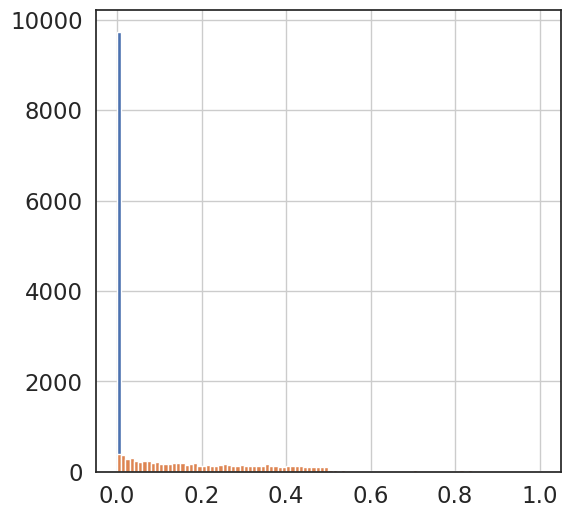

In [20]:
cell_type_psi_df["difference"] = cell_type_psi_df[0] - cell_type_psi_df[1]
cell_type_psi_df["difference"] = np.abs(cell_type_psi_df["difference"])

# make histogram which just rows where sample_label is negative and one where it's positive
cell_type_psi_df[cell_type_psi_df["sample_label"] == "negative"]["difference"].hist(bins=100, range=(0,1))
cell_type_psi_df[cell_type_psi_df["sample_label"] == "positive"]["difference"].hist(bins=100, range=(0,1))

In [21]:
# Figure out which clusters with positive labels have junctions in them with diff < 0.1 
relabel_clusts = cell_type_psi_df[(cell_type_psi_df["sample_label"] == "positive") & (cell_type_psi_df["difference"] < 0.1)].Cluster.unique()

In [22]:
# make new column named "true_label" which is the same as sample_label but for clusters that in relabel_clusts rename them to negative 
cell_type_psi_df["true_label"] = cell_type_psi_df["sample_label"]
cell_type_psi_df.loc[cell_type_psi_df["Cluster"].isin(relabel_clusts), "true_label"] = "negative"
cell_type_psi_df.sort_values(by = ["new_junction_id_index"], inplace = True)
print(cell_type_psi_df.true_label.value_counts(), cell_type_psi_df.sample_label.value_counts())

true_label
negative    12828
positive     6336
Name: count, dtype: int64 sample_label
negative    9732
positive    9432
Name: count, dtype: int64


In [23]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cell_types[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,11.0,1
1,0,1,6.0,1
2,0,2,2.0,1
3,0,3,1.0,1
4,0,4,13.0,1


In [24]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])

In [25]:
# remove gene_id_x column and rename gene_id_y to just gene_id
final_data.drop(columns = ["gene_id_x"], inplace = True)
final_data.rename(columns = {"gene_id_y": "gene_id"}, inplace = True)

In [26]:
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id,new_junction_id_index,new_junc_count,new_cell_type
0,0,12,19.0,24,5.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,11.0,1
1,1163,12,11.0,21,10.0,0.523810,I12-B002433-3_38_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,7.0,1
2,1952,12,17.0,24,7.0,0.708333,N12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,8.0,1
3,1164,12,24.0,44,20.0,0.545455,I12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,21.0,1
4,222,12,3.0,3,0.0,1.000000,B4-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,1.0,0


In [27]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id,junction_id_index,junc_count,new_cell_type
0,0,24,5.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,11.0,1
1,1163,21,10.0,0.523810,I12-B002433-3_38_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,7.0,1
2,1952,24,7.0,0.708333,N12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,8.0,1
3,1164,44,20.0,0.545455,I12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,21.0,1
4,222,3,0.0,1.000000,B4-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,1.0,0


In [28]:
# update cluster_count to be the sum of junction_id_index in each Cluster for each cell
new_clust_counts = sim_data.groupby(["cell_id_index", "Cluster"]).agg({"junc_count": "sum"}).reset_index()
# update column to be cluster_count 
new_clust_counts.rename(columns = {"junc_count": "cluster_count"}, inplace = True)
sim_data.drop(columns = ["cluster_count"], inplace = True)
# merge new_clust_counts with sim_data
sim_data = sim_data.merge(new_clust_counts, on = ["cell_id_index", "Cluster"])

<Axes: xlabel='junc_ratio', ylabel='Count'>

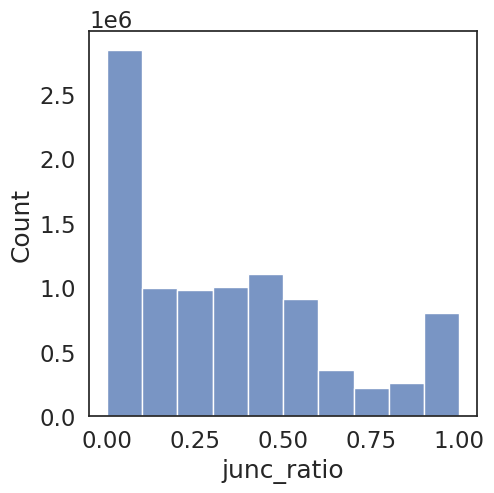

In [29]:
# update juncratio 
sim_data["clustminjunc"] = sim_data["cluster_count"] - sim_data["junc_count"]
sim_data["junc_ratio"] = sim_data["junc_count"] / sim_data["cluster_count"]

# make histogram of junc_ratio
plt.figure(figsize=(5,5))
sns.histplot(sim_data.junc_ratio, bins=10)

In [30]:
sim_data.shape

(9594318, 13)

In [31]:
# juncs clusters labels
juncs_labels = cell_type_psi_df[["new_junction_id_index", "Cluster", "true_label"]]
juncs_labels = juncs_labels.drop_duplicates()

# rename new_junction_id_index to junction_id_index 
juncs_labels.rename(columns = {"new_junction_id_index": "junction_id_index"}, inplace = True)

# merge with sim_data
sim_data = sim_data.merge(juncs_labels, on = ["junction_id_index", "Cluster"])
sim_data.head()

,cell_id_index,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id,junction_id_index,junc_count,new_cell_type,cluster_count,junc_ratio,true_label
0,0,11.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,11.0,1,22.0,0.500000,negative
1,1163,13.0,0.523810,I12-B002433-3_38_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,7.0,1,20.0,0.350000,negative
2,1952,14.0,0.708333,N12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,8.0,1,22.0,0.363636,negative
3,1164,27.0,0.545455,I12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,Mammary_Gland_luminal_epithelial_cell_of_mamma...,1_78692220_78694195,114,Acsl3,0,21.0,1,48.0,0.437500,negative
4,222,1.0,1.000000,B4-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,0,1.0,0,2.0,0.500000,negative


### Prep data for model 

In [32]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [33]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
2405
2405


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/load_cluster_data.py:47: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount).to_sparse_csr()


In [48]:
clust_labels_only = cluster_labels[["Cluster", "true_label"]].drop_duplicates()
simple_data = sim_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "junc_ratio", "junc_count", "cluster_count"]]
# merge with clust_labels_only 
simple_data = simple_data.merge(clust_labels_only, on = ["Cluster"])
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,junc_ratio,junc_count,cluster_count,true_label
0,0,114,Mammary_Gland_basal_cell,0,0.500000,11.0,22.0,negative
1,1163,114,Mammary_Gland_luminal_epithelial_cell_of_mamma...,0,0.350000,7.0,20.0,negative
2,1952,114,Mammary_Gland_luminal_epithelial_cell_of_mamma...,0,0.363636,8.0,22.0,negative
3,1164,114,Mammary_Gland_luminal_epithelial_cell_of_mamma...,0,0.437500,21.0,48.0,negative
4,222,114,Mammary_Gland_basal_cell,0,0.500000,1.0,2.0,negative


In [49]:
# update cell_type column in simple data to what it is in cell_ids_conversion using cell_id_index and make sure it's a category
simple_data.drop(columns = ["cell_type"], inplace = True)
simple_data = simple_data.merge(cell_ids_conversion, on = ["cell_id_index"])
simple_data["cell_type"] = simple_data["cell_type"].astype('category')
simple_data.head()

,cell_id_index,Cluster,junction_id_index,junc_ratio,junc_count,cluster_count,true_label,cell_id,cell_type
0,0,114,0,0.500000,11.0,22.0,negative,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,2
1,1163,114,0,0.350000,7.0,20.0,negative,I12-B002433-3_38_F-1-1_Mammary_Gland_luminal_e...,2
2,1952,114,0,0.363636,8.0,22.0,negative,N12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,2
3,1164,114,0,0.437500,21.0,48.0,negative,I12-B002436-3_39_F-1-1_Mammary_Gland_luminal_e...,2
4,222,114,0,0.500000,1.0,2.0,negative,B4-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,1


/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/vis.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_data_junc["cell_type"] = simple_data_junc["cell_type"].map(cell_type_map)
/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/vis.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  simple_data_junc["cell_type"] = simple_data_junc["cell_type"].astype(str)
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plot

37556
cell_type
2    543
1    483
Name: count, dtype: int64


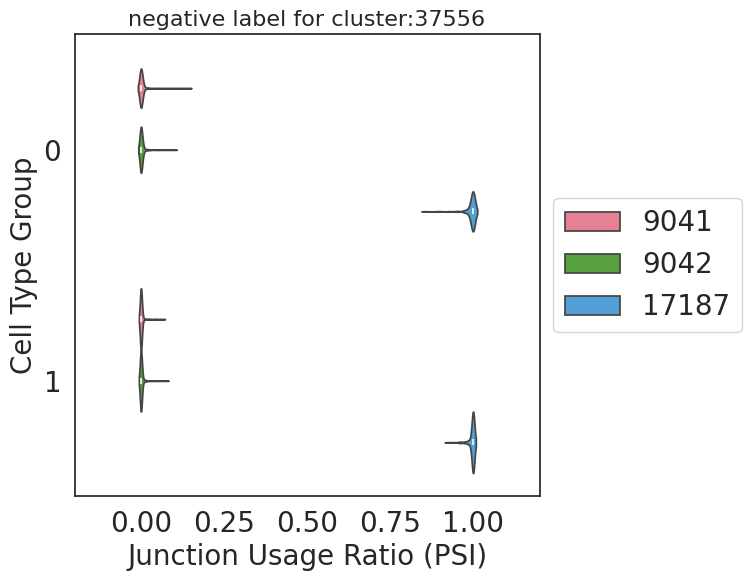

In [54]:
# let's visualize junction usage ratios for a given custer 
# sample clust from simple_data.Cluster.unique()
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
#sim.quick_clust_plot(clust, simple_data)
vis.get_clust_plot(clust, simple_data)

In [55]:
indices = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(sim_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = sim_data['cell_id_index'].max() + 1
num_junctions = sim_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [56]:
indices_counts = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(sim_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = sim_data['cell_id_index'].max() + 1
num_junctions_counts = sim_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [58]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

# remake junction counts and cluster counts sp.coo_matrix for masking analysis
indices = (sim_data.cell_id_index, sim_data.junction_id_index)
junc_counts = sp.coo_matrix((sim_data.junc_count, indices))
cluster_counts = sp.coo_matrix((sim_data.cluster_count, indices))

### Run full model

In [59]:
full_y_tensor

tensor(indices=tensor([[    0,  1163,  1952,  ...,   608,  1992,   255],
                       [    0,     0,     0,  ..., 19163, 19163, 19163]]),
       values=tensor([11.,  7.,  8.,  ...,  2., 14.,  1.]),
       size=(2405, 19164), nnz=9594318, layout=torch.sparse_coo)

In [60]:
full_total_counts_tensor

tensor(indices=tensor([[    0,  1163,  1952,  ...,   608,  1992,   255],
                       [    0,     0,     0,  ..., 19163, 19163, 19163]]),
       values=tensor([22., 20., 22.,  ...,  3., 20.,  1.]),
       size=(2405, 19164), nnz=9594318, layout=torch.sparse_coo)

In [61]:
reload(factor_model)
best_K = 2
K = best_K
print(K) 

#input_conc = 50
# set input_conc to inf
input_conc = float('inf')
plot_bb=False
#input_conc = None
all_results, variable_sizes = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=3, use_global_prior=True, K=K, lr=0.1, input_conc_prior=input_conc, loss_plot=False, num_epochs=100, save_to_file = False)

Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
Using prior for a and b per junction to model average behaviour!


2.3.0+cu121
12.1
2
Random seeds: [5945, 4835, 1591]
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 5945
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 388077452.94385844
Epoch 25, Elbo loss: 149280153.03722075
Epoch 50, Elbo loss: 78355092.06936738


In [ ]:
# figure out which index in all_results has the lowest final loss
losses = [result["losses"][-1] for result in all_results]
# get number of epochs for each initialization
num_epochs = [len(result["losses"]) for result in all_results]

# make a quick plot of the losses
plt.plot(losses)
plt.xlabel("Initialization")
plt.ylabel("Final Loss")
# make each loss value with a dot 
plt.scatter(range(len(losses)), losses)
# also mark the number of epochs
for i in range(len(losses)):
    plt.text(i, losses[i], str(num_epochs[i]), size="small")
# mark the lowest loss red
plt.scatter(np.argmin(losses), np.min(losses), color="red")

In [ ]:
# Let's get assign matrix for each initialization
assign_matrices = [result["summary_stats"]["assign"]["mean"] for result in all_results]
len(assign_matrices)

In [ ]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *
import cost_correlation_assign
from cost_correlation_assign import *

# import reload 
from importlib import reload
reload(masking)

corrs, matchings = compare_assignments(assign_matrices)

In [ ]:
# plot the correlation matrix
plt.imshow(corrs, cmap="viridis")

# add colorbar
plt.colorbar()
# make the ticks show the initialization number
plt.xticks(range(len(corrs)), range(0, len(corrs)))
plt.yticks(range(len(corrs)), range(0, len(corrs)))
# print the correlation values
for i in range(len(corrs)):
    for j in range(len(corrs)):
        plt.text(i, j, f"{corrs[i, j]:.2f}", ha="center", va="center")

In [ ]:
def average_pairwise_correlation(corrs):
    # Use tril_indices to access the lower triangle excluding the diagonal
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.mean(corrs[i, j])

def median_pairwise_correlation(corrs):
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.median(corrs[i, j])

def min_pairwise_correlation(corrs):
    i, j = np.tril_indices_from(corrs, k=-1)
    return np.min(corrs[i, j])

# Calculate the average pairwise correlation
average_corr = average_pairwise_correlation(corrs)
print(f"Average Pairwise Correlation: {average_corr}")

consistency_index = average_corr / 1.0  # Since correlation's maximum is 1
print(f"Consistency Index: {consistency_index}")

median_corr = median_pairwise_correlation(corrs)
print(f"Median Pairwise Correlation: {median_corr}")

min_corr = min_pairwise_correlation(corrs)
print(f"Minimum Pairwise Correlation: {min_corr}")

In [ ]:
# get the index of initialization with the lowest loss
best_init = np.argmin(losses)
print("The best initialization was: ", best_init)

# extract latent variables for just first seed used 
latent_vars = all_results[best_init]['summary_stats'] 

pi = latent_vars["pi"]["mean"] # overall contribution of each factor to cell population, one value per k
dir_conc = latent_vars["dir_conc"]["mean"] # one scaling value 
assign_post = latent_vars["assign"]["mean"]
psis = latent_vars["psi"]["mean"] # psi is the probability of a junction being used in a cluster
a = latent_vars["a"]["mean"] 
b = latent_vars["b"]["mean"] 
#bb_conc = latent_vars["bb_conc"]["mean"] # concentration parameter for beta-binomial distribution

print(a)
print(b)

print("The inferred concentration parameter is: " + str(dir_conc))
print("The inferred pi parameter is: " + str(pi))
#print("The inferred bb_conc parameter is: " + str(bb_conc))

In [ ]:
# print shape of psi, we need this later for the extraction of mus and variances from variational params from guide 
print(psis.shape)

In [ ]:
cell_types_id = sim_data[["cell_id", "cell_id_index", "new_cell_type"]].drop_duplicates()
# reorder by cell_id_index
cell_types_id = cell_types_id.sort_values(by = ["cell_id_index"])
cell_types_id.head()

In [ ]:
cell_types_id.new_cell_type.value_counts()

In [ ]:
assign_post_df = pd.DataFrame(assign_post)

In [ ]:
# print pyro params guide variables 
print("The pyro params guide variables are: ")
pyro.get_param_store().keys()

In [ ]:
# get length of params in each key of param store
for key in pyro.get_param_store().keys():
    print(key, len(pyro.get_param_store()[key]))

In [ ]:
J = psis.shape[1]
print(K * J)

In [ ]:
# Let's extract the values in .0.loc and .0.scale for each key in param store 
psis_mus = pyro.get_param_store()["AutoGuideList.0.loc"]
psis_loc = pyro.get_param_store()["AutoGuideList.0.scale"]

# reshape psis_mus and psis_loc to be K x J
psis_mus = psis_mus.reshape(K, J)
psis_loc = psis_loc.reshape(K, J)

# get the shape of psis_mus
psis_mus.shape, psis_loc.shape

In [ ]:
J = psis.shape[1]
jj = np.random.randint(J)
jj = 163
from scipy.stats import beta

if plot_bb:

    # Generate values for the x-axis
    x = np.linspace(0, 1, 1000)

    success_probs = psis[:,jj]
    bbconc_param = bb_conc
    print(f"The bb conc param is {bbconc_param}")
    conc_params = [10, bbconc_param, 1000]
    fig, axs = plt.subplots(1, 4, figsize=(15, 5))
    # Define a single legend for all curves
    legend_labels = []

    for i, conc_param in enumerate(conc_params):

        # Plot individual curves for each success probability
        for j, success_prob in enumerate(success_probs):
            # Calculate shape parameters for the Beta distribution
            bb_alpha = success_prob * conc_param
            bb_beta = (1 - success_prob) * conc_param

            # Calculate the probability density function (PDF) of the beta distribution
            pdf = beta.pdf(x, bb_alpha, bb_beta)

            # Plot the Beta distribution
            # axs[i].plot(x, pdf, label=f'Success Prob {j+1}: {success_prob:.2f}')
            # Plot the Beta distribution and store the label for the legend
            line, = axs[i].plot(x, pdf, label=f'Success Prob {jj+1}: {success_prob:.2f}')
            if i == 0:  # Add legend labels only once
                legend_labels.append(line.get_label())
            
        axs[i].set_title(f'Beta Distribution (Cell State: {conc_param})', fontsize=10)
        axs[i].set_xlabel('x')
        axs[i].set_ylabel('Probability Density')
        axs[i].grid(True)

    # Also plot the Beta distribution average junction behaviour using a_j and b_j values
    # in this case just a[1] and b[1] for the current junction 
    bb_alpha = a[jj]
    bb_beta = b[jj]
    bb_avg = bb_alpha / (bb_alpha+bb_beta)
    print(f"The average junction behaviour is: {bb_avg:.2f}")
    pdf = beta.pdf(x, bb_alpha, bb_beta)
    axs[3].plot(x, pdf, label=f'Average Junction Behaviour')
    axs[3].set_title('Beta Distribution (Average Junction Behaviour)', fontsize=10)
    axs[3].set_xlabel('x')
    axs[3].set_ylabel('Probability Density')
    axs[3].grid(True)
    
    # extract only unique values from legend lines 
    fig.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    # print the plot
    # print axs[2]

    plt.show()

In [ ]:
psis_mus.shape

In [ ]:
j = np.random.randint(J)

# let's do a sanity check that the mus and scales of PSIs would correspond to what we sample from the beta distribution posterior
# sample j from J 
print(f"Junction {j}")

# get mu_j and scale_j for junction j from variational params
mu_j = psis_mus[:,j]
scale_j = psis_loc[:,j]

print(f"Mean of PSIs: {mu_j}")
print(f"Scale of PSIs: {scale_j}")

# for each mu_kj and scale_kj we sample from a normal distribution with mean mu_kj and scale scale_kj
# use torch normal distirbution to sample one value for each k 

# sample from normal distribution, one value for each k
sampled_vals = torch.normal(mu_j, scale_j)

# calculate sigmoid of each value using torch 
sigmoid_vals = torch.sigmoid(sampled_vals)
sigmoid_vals

In [ ]:
psis[:,j] # sometimes the order of K in the psis and sigmoid vals seems to be switched?!

In [ ]:
# initiate new tensor to store the sigmoid values 
psis_variational = torch.zeros(K, J)

# collect all the sigmoids values for each junction k 
for j in range(J):
    mu_j = psis_mus[:,j]
    scale_j = psis_loc[:,j]
    sampled_vals = torch.normal(mu_j, scale_j)
    sigmoid_vals = torch.sigmoid(sampled_vals)
    psis_variational[:,j] = sigmoid_vals

In [ ]:
psis_torch = torch.tensor(psis)
psis_torch

In [ ]:
psis_variational

In [ ]:
# compare psis and psis_variational
print("The correlation between the true PSIs and the variational PSIs is: ")
correlation = torch.nn.functional.cosine_similarity(psis_variational, psis_torch, dim=1)
correlation

### Evaluate latent factor space

In [ ]:
# make UMAP using average assign_post across seeds and color points by cell_type 
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

# run UMAP on assign_post matrix
reducer = umap.UMAP()
embedding = reducer.fit_transform(assign_post)

In [ ]:
cell_ids_conversion

In [ ]:
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(6, 6))

cell_types = cell_ids_conversion.cell_type

cell_types_unique = cell_types.unique()
cell_type_colors = sns.color_palette("tab20", len(cell_types_unique))
cell_type_dict = dict(zip(cell_types_unique, cell_type_colors))
cell_colors = cell_types.map(cell_type_dict)

# Plot the UMAP embedding
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=35, c=cell_colors
)

# Create legend handles and labels
legend_handles = [mpatches.Patch(color=color, label=cell_type) for cell_type, color in cell_type_dict.items()]

# Add legend to the plot
plt.legend(handles=legend_handles)

In [ ]:
assign_post

In [ ]:
# make simple scatter plot of assign_post matrix
plt.figure(figsize=(6, 6))
plt.scatter(assign_post[:,0], assign_post[:,1], c=cell_colors)
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")

In [ ]:
# make sorted barplot of pi
pi_df = pd.DataFrame(pi, columns=["pi"])
# add factor number column 
pi_df["Factor"] = "Facotor"+pi_df.index.astype(str)
pi_df = pi_df.sort_values(by="pi", ascending=False)
print(pi_df.head())

# make barplot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Factor", y="pi", data=pi_df, palette="viridis")
ax.set_xlabel("Factor")
# rotate x labels 90 degres 
plt.xticks(rotation=90, size=12)

ax.set_ylabel("pi")
ax.set_title("Overall contribution of each factor to cell population")

In [ ]:
# convert into a data frame
psi_df = pd.DataFrame(psis)

In [ ]:
# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
# Get collors 
colors = sns.color_palette("tab20", num_unique_types)

# Create a dictionary mapping cell types to colors
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}

# Get cell type labels for each cell
cell_types = cell_ids_conversion.cell_type.values

# Create a list of colors for each cell based on its cell type
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

# Use the custom color palette in your clustermap
cluster = sns.clustermap(
    data=assign_post,
    method='complete',
    cmap="viridis",
    annot=False,
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Post assignment'} 
)

In [ ]:
# Now let's implement ALBF so can see which junctions are selected to be differentially spliced and then see if this corresponds to the true labels that were simulated
# load ALBF code from differential_splicing.py
import differential_splicing
reload(differential_splicing)

In [ ]:
psis_mus

In [ ]:
psis_loc

In [ ]:
psis_mus.shape

In [ ]:
psis[:, 2]

In [ ]:
junction_ids_conversion[junction_ids_conversion["new_junction_id_index"] == 18332]

In [ ]:
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
#sim.quick_clust_plot(clust, simple_data)
quick_clust_plot(71638, simple_data)

In [ ]:
def plot_logit_normal_distribution_with_samples(psis_mus, psis_loc, psis, j):

    """
    Plot the logit-normal distributions for each row using the mean and standard deviation provided for a specific column index j.

    :param psis_mus: Tensor of shape (2, N), means of the logit-normal distributions
    :param psis_loc: Tensor of shape (2, N), standard deviations of the logit-normal distributions
    :param j: Column index to select the mean and standard deviation
    """
    psis_mus = psis_mus.cpu().detach().numpy()  # Convert tensors to numpy arrays
    psis_loc = psis_loc.cpu().detach().numpy()
    
    # Extract the means and standard deviations for the specific column j
    means = psis_mus[:, j]
    std_devs = psis_loc[:, j]
    psi_samples_final = psis[:, j]

    # Create a plot
    plt.figure()

    for mean, std_dev, final_sample in zip(means, std_devs, psi_samples_final):
        # Sample values from the normal distribution of y
        y_samples = np.random.normal(mean, std_dev, 10000)
        # Transform y to psi
        psi_samples = 1 / (1 + np.exp(-y_samples))

        # Plot the histogram of the psi samples to show the distribution
        plt.hist(psi_samples, bins=100, density=True, alpha=0.6, label=f'Logit-Normal Dist (mean={mean}, std={std_dev})')

        # Plot the final sampled values of psi as a line
        plt.axvline(final_sample, color='grey', linestyle='--', linewidth=1, label=f'Sampled Value (psi={final_sample})')
        plt.xlim(0, 1)

    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.title('Logit-Normal Distributions for Psi with Sampled Values')
    plt.grid(True)
    plt.show()

In [ ]:
plot_logit_normal_distribution_with_samples(psis_mus, psis_loc, psis, 18332)

In [ ]:
import torch

def combined_mean_variance(means, variances):
    eps = 1e-10  # Small value to ensure numerical stability
    variances = torch.clamp(variances, min=eps)
    inv_variances = 1 / variances
    combined_variance = 1 / torch.sum(inv_variances, dim=0)
    combined_mean = combined_variance * torch.sum(means * inv_variances, dim=0)
    return combined_mean, combined_variance

def gaussian_pdf(x, mean, std):
    eps = 1e-10  # Small value to ensure numerical stability
    var = std ** 2 + eps
    denom = (2 * torch.pi * var) ** 0.5
    num = torch.exp(- (x - mean) ** 2 / (2 * var))
    return num / denom

def check_for_nan_inf(tensor, name):
    if torch.isnan(tensor).any():
        print(f"{name} contains NaN values")
    if torch.isinf(tensor).any():
        print(f"{name} contains infinity values")

def likelihood_under_null(means, variances):
    eps = 1e-10  # Small value to ensure numerical stability
    combined_mean, combined_variance = combined_mean_variance(means, variances)
    combined_std = combined_variance ** 0.5

    # Calculate the combined Gaussian PDF at zero
    combined_pdf_zero = gaussian_pdf(torch.tensor(0.0), combined_mean, combined_std)
    combined_pdf_zero = torch.clamp(combined_pdf_zero, min=eps)
    
    # Calculate the product of Gaussian PDFs evaluated at zero for each mean and std
    # DO SUM OF LOGS INSTEAD!
    product_pdfs_zero = torch.prod(gaussian_pdf(torch.tensor(0.0), means, variances ** 0.5), dim=0)
    product_pdfs_zero = torch.clamp(product_pdfs_zero, min=eps)
    
    # Compute the full likelihood under null hypothesis
    likelihood_H0 = product_pdfs_zero / combined_pdf_zero
    
    # Debugging prints
    print("Combined Mean:", combined_mean)
    print("Combined Variance:", combined_variance)
    print("Combined PDF Zero:", combined_pdf_zero)
    print("Product PDFs Zero:", product_pdfs_zero)
    print("Likelihood H0:", likelihood_H0)
    
    # Check for NaN or infinity values
    check_for_nan_inf(combined_mean, "Combined Mean")
    check_for_nan_inf(combined_variance, "Combined Variance")
    check_for_nan_inf(combined_pdf_zero, "Combined PDF Zero")
    check_for_nan_inf(product_pdfs_zero, "Product PDFs Zero")
    check_for_nan_inf(likelihood_H0, "Likelihood H0")
    
    return likelihood_H0

def compute_albf(psis, psis_mus, psis_loc):
    # Compute likelihood under H_0 for each junction
    likelihood_H0 = likelihood_under_null(psis_mus, psis_loc)

    # Compute ALBF for each junction
    albf = -torch.log(likelihood_H0)
    
    # Convert -0.0 to 0
    albf = torch.where(albf == -0.0, torch.tensor(0.0), albf)
    return albf, likelihood_H0

In [ ]:
psis.shape

In [ ]:
albf, l0 = compute_albf(psis, psis_mus, psis_loc+0.0001)
print(albf.shape)

In [ ]:
l0 = l0.detach().cpu()
l0

In [ ]:
albf = albf.detach().cpu()
albf_df = pd.DataFrame(albf, columns=["ALBF"])
albf_df["new_junction_id_index"] = range(albf_df.shape[0])
albf_df.iloc[7898]

In [ ]:
albf_df.sort_values(by="ALBF", ascending=False)

In [ ]:
sns.histplot(albf.detach().cpu())

In [ ]:
# turn psis into df and merge with combined_df give new junction_id_index column first 
psis_df = pd.DataFrame(psis.T)
psis_df["new_junction_id_index"] = psis_df.index
psis_df = psis_df.merge(albf_df, on = ["new_junction_id_index"])
psis_df.head()

In [ ]:
# add difference column 1-0 
psis_df["difference"] = psis_df[1] - psis_df[0]
psis_df["difference"] = np.abs(psis_df["difference"])
psis_df.head()

In [ ]:
# plot ALBF vs difference
plt.figure(figsize=(5,5))
sns.scatterplot(data = psis_df, x = "difference", y = "ALBF")
# calcualte spearman correlation between ALBF and difference
correlation = psis_df["ALBF"].corr(psis_df["difference"], method="spearman")
print(correlation)

In [ ]:
cell_type_psi_df = cell_type_psi_df.merge(albf_df, on = ["new_junction_id_index"])

In [ ]:
# make density plot of ALBF vlaues and color by true_label
plt.figure(figsize=(6, 6))
sns.kdeplot(data=cell_type_psi_df, x="ALBF", hue="true_label", fill=True)
plt.xlabel("ALBF")


In [ ]:
cell_type_psi_df.ALBF.min()

In [ ]:
subdat = cell_type_psi_df[cell_type_psi_df["true_label"] == "positive"].sort_values(by="ALBF", ascending=True)
plt.figure(figsize=(6, 6))
sns.kdeplot(data=subdat, x="ALBF", hue="true_label", fill=True)
plt.xlabel("ALBF")

In [ ]:
cell_type_psi_df.sort_values("ALBF")

In [ ]:
psis[:, 631]

In [ ]:
psis_variational[:, 631]

In [ ]:
quick_clust_plot(344, simple_data)